<a href="https://colab.research.google.com/github/ishivansmishra/ChatBot/blob/main/Multi_AI_RAG_CHATBOTS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install langchain langgraph cassio

In [2]:
import cassio
## Connection of the Astra Db
from google.colab import userdata

astra_token = userdata.get("ASTRA_TOKEN")
api_id = userdata.get("API_ENDPOINT")

cassio.init(token=astra_token,database_id=api_id)


In [3]:
!pip install langchain_community

In [4]:
!pip install -U tiktoken langchain-groq langchainhub langchain langgraph langchain_huggingface

In [5]:

from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import WebBaseLoader

urls = [
    "https://lilianweng.github.io/posts/2023-06-23-agent/",
    "https://lilianweng.github.io/posts/2023-03-15-prompt-engineering/",
    "https://lilianweng.github.io/posts/2023-10-25-adv-attack-llm/"
]

## Load
docs = [WebBaseLoader(url).load() for url in urls]
docs_list = [item for sublist in docs for item in sublist]
text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(chunk_size=500,chunk_overlap=0)
docs_split= text_splitter.split_documents(docs_list)

/tmp/ipykernel_8514/814613432.py:2: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import WebBaseLoader


In [6]:
from langchain_huggingface import HuggingFaceEmbeddings
embeddings = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [7]:
from langchain_community.vectorstores.cassandra import Cassandra
astra_vector_store = Cassandra(embedding = embeddings,table_name="qa_mini_demo",session=None,keyspace=None)


In [8]:

astra_vector_store.add_documents(docs_split)
print("Inserted %i headlines,",len(docs_split))


Inserted %i headlines, 88


In [9]:
retriever = astra_vector_store.as_retriever()
retriever.invoke("What is agentic ai")

[Document(id='65c7660288de4dc089b1cdfeab0382d6', metadata={'description': 'Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistakes and refine them for future steps, thereby improving the quality of final results.\n\n\nMemory\n\nShort-term memory: I would consider all the in-context lear

In [10]:
## Langgraph application

from typing import Literal
from langchain_core.prompts import ChatPromptTemplate
from pydantic import BaseModel, Field

In [11]:
class RouteQuery(BaseModel):
  """ Route a user Query to the most relevant datasource. """
  datasource: Literal["vectorstore","wiki_search"] = Field(
      ...,
      description = "Given a user question choose to route it to wikipedia or a vectorstore"
  )


In [12]:
from langchain_groq import ChatGroq
from google.colab import userdata

import os
groq_api_key = userdata.get('GROQ_API_KEY')

In [13]:
llm = ChatGroq(groq_api_key=groq_api_key,model_name="llama-3.3-70b-versatile")

In [14]:
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.7', 'langchain': '1.3.9'}}, profile={'name': 'Llama 3.3 70B Versatile', 'release_date': '2024-12-06', 'last_updated': '2024-12-06', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 32768, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x78a6853ec3e0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x78a684b54b00>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [15]:
structured_llm_router = llm.with_structured_output(RouteQuery)

In [16]:
## Prompt
system = """ You are an expert at routing a user question to a vectorstore or wikipedia.
The vectorstore contains documents related to agents, prompt engineerin, and adversarial attacks.
Use the vectorstore for questions on these topicvs. Otherwise, use wiki-search"""

route_prompt = ChatPromptTemplate.from_messages(
    [
        ("system",system),
        ("human","{question}"),
    ]
)

question_router = route_prompt | structured_llm_router

In [17]:
print(question_router.invoke({
    "question":"What is ai agents"
}))

datasource='vectorstore'


In [18]:
print(question_router.invoke({
    "question":"What is meaning of prime minster"
}))

datasource='wiki_search'


In [19]:
!pip install Wikipedia
!pip install langchain_community

In [20]:
from langchain_community.utilities import WikipediaAPIWrapper
from langchain_community.tools import WikipediaQueryRun

api_wrapper = WikipediaAPIWrapper(top_k_results=1,doc_content_chars_max=200)
wiki = WikipediaQueryRun(api_wrapper=api_wrapper)

In [ ]:
wiki.run("Tell me about jawaharlal nehru")

JSONDecodeError: Expecting value: line 1 column 1 (char 0)

In [23]:
## AI agent application using Langgraph

from typing import List
from typing_extensions import TypedDict

class GraphState(TypedDict):
  """
  Represents the state of our graph.

  Attributes:
         question : question
         generation : LLM Generation
         documents : list of documents
  """
  question: str
  generation : str
  documents:  List[str]

In [28]:
from langchain_core.documents import Document
def retrieve(state):
 """
 Retrieve documents
 Args:
   state(dict): The current graph state
  Returns:
   state(dict): New Key added to state, documents, that contains retrieved documents
 """

 print("----- Retrieve ----")
 questions=state["question"]

 #Retrieval
 documents = retriever.invoke(questions)
 return{"documents":documents,"questions":questions}

In [29]:
def wiki_search(state):
  """
  wiki search based on the re-phrased question.

  Args:
     state(dict): the current graph state

  Returns:
    state(dict): updates documents key with appended web results
  """

  print("---wikipedia----")
  print("----Hello----")

  question = state["question"]
  print(question)

  docs = wiki.invoke({"query":question})
  wiki_results = docs
  wiki_results = Document(page_content=wiki_results)
  return {"document":wiki_results,"question":question}

In [30]:
## Edges
def route_question(state):
  """
  Route question to wiki search or RAG.
  Args:
     state(dict): The current graph state
  Returns:
     str: Next node to call


  """

  print("---Route Question---")
  question = state["question"]
  source = question_router.invoke({"question":question})
  if source.datasource == "wiki_search":
    print("--Route Question to wiki search")
    return "wiki_search"
  elif source.datasource == "vectorstore":
    print("--Route Question to RAG")
    return "vectorstore"


In [34]:
from langgraph.graph import END,StateGraph,START
workflow = StateGraph(GraphState)
## Define the nodes
workflow.add_node("wiki_search",wiki_search)
workflow.add_node("retrieve",retrieve)

workflow.add_conditional_edges(
    START,
    route_question,
    {
        "wiki_search":"wiki_search",
        "vectorstore":"retrieve",
    },
)
workflow.add_edge("retrieve",END)
workflow.add_edge("wiki_search",END)

## Compile
app = workflow.compile()

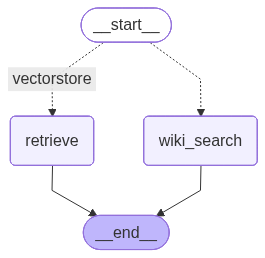

In [37]:
from IPython.display import Image, display

try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception as e:
    print(e)
    app.get_graph().print_ascii()